In [1]:
# CELDA 1 - IMPORTS Y RUTAS

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta base del notebook: ml/notebooks/
# Subimos dos niveles para llegar a ml/ y de ahi a data/raw/train

NOTEBOOK_DIR = Path().resolve()
ML_DIR = NOTEBOOK_DIR.parent
RAW_TRAIN_DIR = ML_DIR / "data" / "raw" / "train"
RAW_TEST_DIR = ML_DIR / "data" / "raw" / "test"

# Verificamos

assert RAW_TRAIN_DIR.exists(), f"No encuentro train en: {RAW_TRAIN_DIR}"
assert RAW_TEST_DIR.exists(), f"No encuentro test en: {RAW_TEST_DIR}"

print(f"Train: {RAW_TRAIN_DIR}")
print(f"Test:  {RAW_TEST_DIR}")

Train: C:\Users\Juan\Desktop\sign-language-translator\ml\data\raw\train
Test:  C:\Users\Juan\Desktop\sign-language-translator\ml\data\raw\test


In [2]:
# CELDA 2 - CONTEO DE IMAGENES
# Cada subcarpeta dentro de train/ es una clase, queremos saber cuantas imagenes tiene cada una.
# Esto nos dira si el dataset esta balanceado o no.

clases = sorted(os.listdir(RAW_TRAIN_DIR))
conteo = {}

for clase in clases:
    carpeta = RAW_TRAIN_DIR / clase
    if carpeta.is_dir():
        conteo[clase] = len(list(carpeta.iterdir()))

df_conteo = pd.DataFrame(list(conteo.items()), columns=["clase", "num_imagenes"])
print(df_conteo.to_string(index=False))
print(f"\nTotal clases: {len(df_conteo)}")
print(f"Total imagenes: {df_conteo['num_imagenes'].sum()}")
print(f"Min por clase: {df_conteo['num_imagenes'].min()}")
print(f"Max por clase: {df_conteo['num_imagenes'].max()}")

  clase  num_imagenes
      A          3000
      B          3000
      C          3000
      D          3000
      E          3000
      F          3000
      G          3000
      H          3000
      I          3000
      J          3000
      K          3000
      L          3000
      M          3000
      N          3000
      O          3000
      P          3000
      Q          3000
      R          3000
      S          3000
      T          3000
      U          3000
      V          3000
      W          3000
      X          3000
      Y          3000
      Z          3000
    del          3000
nothing          3000
  space          3000

Total clases: 29
Total imagenes: 87000
Min por clase: 3000
Max por clase: 3000


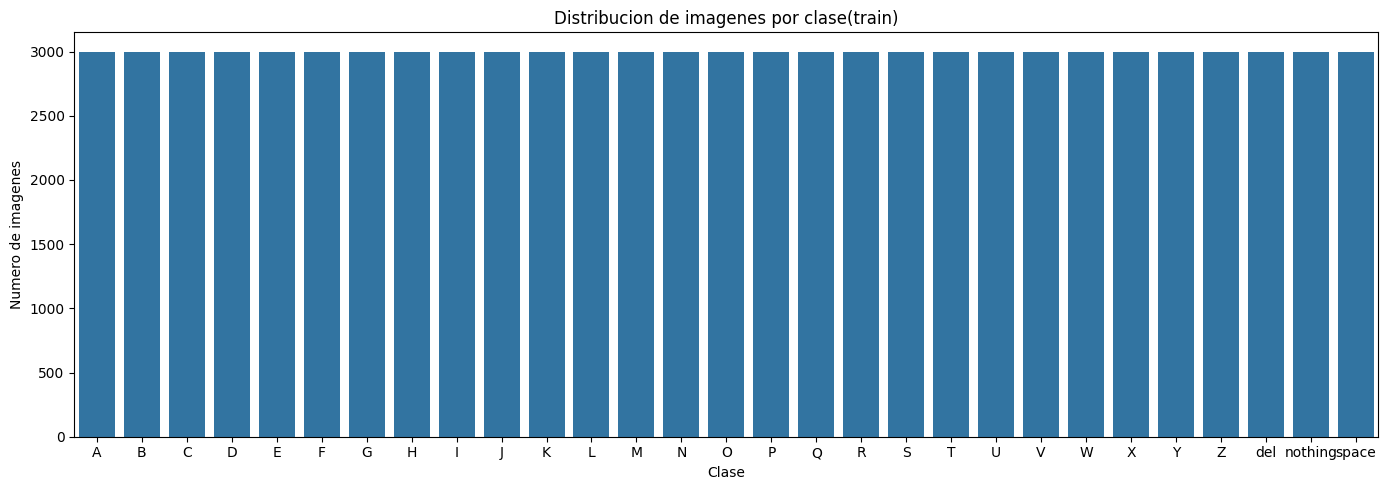

In [3]:
# CELDA 3 - GRAFICO DE DISTRIBUCION DE CLASES

plt.figure(figsize=(14, 5))
sns.barplot(data=df_conteo, x="clase", y="num_imagenes")
plt.title("Distribucion de imagenes por clase(train)")
plt.xlabel("Clase")
plt.ylabel("Numero de imagenes")
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_distribucion_clases.png")
plt.show()

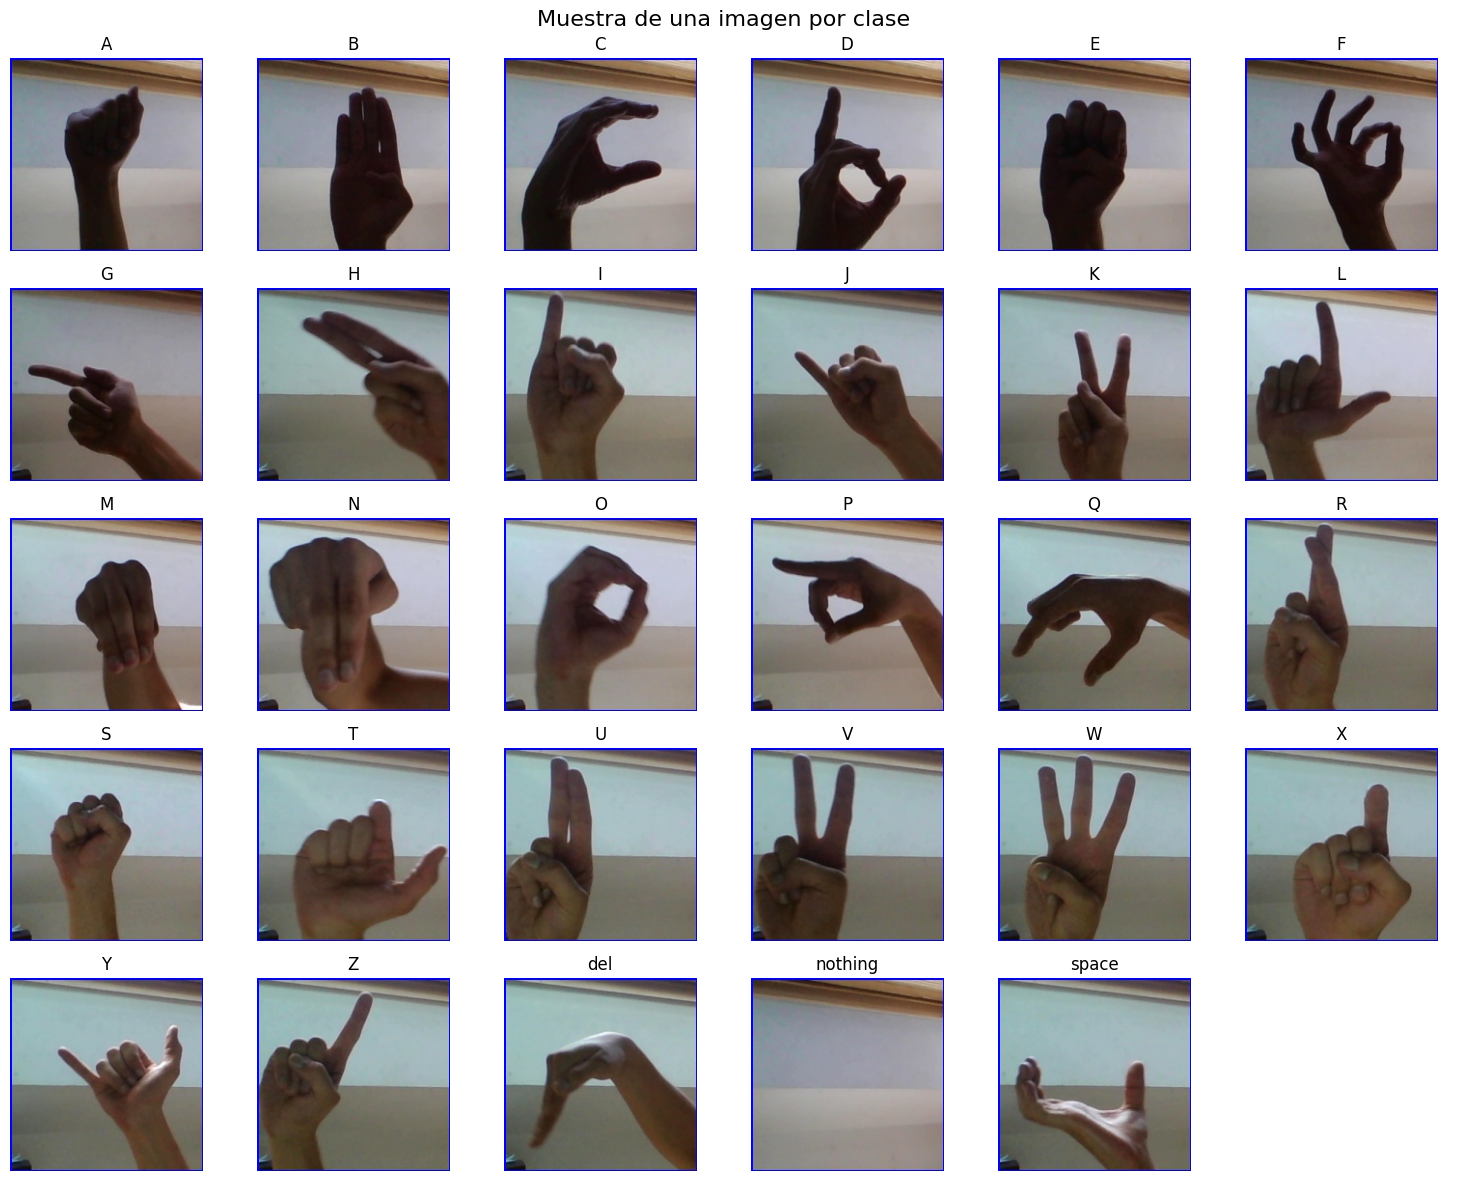

In [4]:
# CELDA 4 - MUESTRA IMAGENES POR CLASE

import cv2

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for i, clase in enumerate(clases):
    carpeta = RAW_TRAIN_DIR / clase
    primera_imagen = list(carpeta.iterdir())[0]
    img = cv2.imread(str(primera_imagen))
    if img is None:
        print(f"ERROR leyendo clase {clase}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(clase)
    axes[i].axis("off")

axes[29].axis("off")

plt.suptitle("Muestra de una imagen por clase", fontsize=16)
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_muestra_clases.png")
plt.show()

In [5]:
# CELDA 5 - RESOLUCION DE IMAGENES

resoluciones = {}

for clase in clases:
    carpeta  = RAW_TRAIN_DIR / clase
    primera_imagen = list(carpeta.iterdir())[0]
    img = cv2.imread(str(primera_imagen))
    h, w, c = img.shape
    resoluciones[clase] = (w, h)
    
df_res = pd.DataFrame(
    [(clase, w, h) for clase, (w, h) in resoluciones.items()], 
    columns=["clase", "ancho", "alto"]
)

print(df_res.to_string(index=False))
print(f"\nResoluciones unicas: {df_res[['ancho', 'alto']].drop_duplicates().values}")

  clase  ancho  alto
      A    200   200
      B    200   200
      C    200   200
      D    200   200
      E    200   200
      F    200   200
      G    200   200
      H    200   200
      I    200   200
      J    200   200
      K    200   200
      L    200   200
      M    200   200
      N    200   200
      O    200   200
      P    200   200
      Q    200   200
      R    200   200
      S    200   200
      T    200   200
      U    200   200
      V    200   200
      W    200   200
      X    200   200
      Y    200   200
      Z    200   200
    del    200   200
nothing    200   200
  space    200   200

Resoluciones unicas: [[200 200]]


In [6]:
# CELDA 6 - RESOLUCION TEST

imagenes_test = list(RAW_TEST_DIR.iterdir())
print(f"Total imagenes test: {len(imagenes_test)}")
print(f"Ejemplo de nombres: {[f.name for f in imagenes_test[:5]]}")

img = cv2.imread(str(imagenes_test[0]))
h, w, c = img.shape
print(f"Resolucion: {w}x{h}px")

Total imagenes test: 28
Ejemplo de nombres: ['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg']
Resolucion: 200x200px


In [9]:
# CELDA 7 - PRUEBA MEDIAPIPE

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

model_path = ML_DIR / "hand_landmarker.task"
if not model_path.exists():
    print("Descargando modelo...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
        str(model_path)
    )
    print("Descargado")
    
base_options = python.BaseOptions(model_asset_path=str(model_path))
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

# Probamos una imagen A
img_a = mp.Image.create_from_file(str(RAW_TRAIN_DIR / "A" / "A1.jpg"))
results_a = detector.detect(img_a)

print("=== Imagen A ===")
if results_a.hand_landmarks:
    landmarks = results_a.hand_landmarks[0]
    print(f"Landmarks detectados: {len(landmarks)}")
    print(f"Landmark 0 (muñeca): x={landmarks[0].x:.4f}, y={landmarks[0].y:.4f}, z={landmarks[0].z:.4f}")
else:
    print("No se detecto mano")

# Probamos con nothing
img_nothing = mp.Image.create_from_file(str(RAW_TRAIN_DIR / "nothing" / "nothing1.jpg"))
results_nothing = detector.detect(img_nothing)

print("\n=== Imagen nothing ===")
if results_nothing.hand_landmarks:
    print(f"Landmarks detectados: {len(results_nothing.hand_landmarks[0].landmark)}")
else:
    print("No se detecto mano")

=== Imagen A ===
Landmarks detectados: 21
Landmark 0 (muñeca): x=0.4420, y=0.5801, z=-0.0000

=== Imagen nothing ===
No se detecto mano


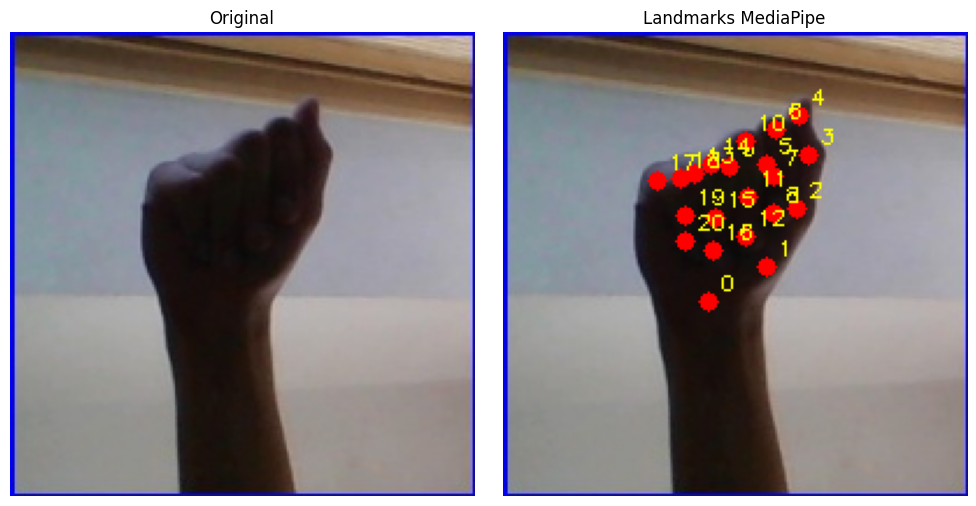

In [10]:
# CELDA 8 - VISUALIZACION DE LANDMARKS SOBRE IMAGEN

img_a_original = cv2.imread(str(RAW_TRAIN_DIR / "A" / "A1.jpg"))
img_a_rgb = cv2.cvtColor(img_a_original, cv2.COLOR_BGR2RGB)

results = detector.detect(mp.Image.create_from_file(str(RAW_TRAIN_DIR / "A" / "A1.jpg")))
landmarks = results.hand_landmarks[0]

h, w = img_a_rgb.shape[:2]

# Dibujar landmarks
img_con_landmarks = img_a_rgb.copy()
for i, lm in enumerate(landmarks):
    cx, cy = int(lm.x * w), int(lm.y * h)
    cv2.circle(img_con_landmarks, (cx, cy), 4, (255, 0, 0), -1)
    cv2.putText(img_con_landmarks, str(i), (cx + 5, cy -5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3,(255, 255, 0), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_a_rgb)
ax1.set_title("Original")
ax1.axis("off")
ax2.imshow(img_con_landmarks)
ax2.set_title("Landmarks MediaPipe")
ax2.axis("off")

plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_landmarks.png")
plt.show()

In [19]:
# CELDA 9 - TASA DE DETECCION POR CLASE

MUESTRA_POR_CLASE = 3000
resultados_deteccion = {}

for clase in clases:
    carpeta = RAW_TRAIN_DIR / clase
    imagenes = list(carpeta.iterdir())[:MUESTRA_POR_CLASE]
    detectadas = 0
    
    for img_path in imagenes:
        img = mp.Image.create_from_file(str(img_path))
        result = detector.detect(img)
        if result.hand_landmarks:
            detectadas += 1
    tasa = detectadas / len(imagenes) * 3000
    resultados_deteccion[clase] = tasa
    print(f"{clase}: {tasa:.1f}%")
    
print(f"\nMedia general (sin nothing): {sum(v for k,v in resultados_deteccion.items() if k != 'nothing') / 28:.1f}%")

A: 2187.0%
B: 2200.0%
C: 1957.0%
D: 2461.0%
E: 2308.0%
F: 2866.0%
G: 2424.0%
H: 2372.0%
I: 2380.0%
J: 2572.0%
K: 2696.0%
L: 2525.0%
M: 1597.0%
N: 1272.0%
O: 2263.0%
P: 2047.0%
Q: 2112.0%
R: 2542.0%
S: 2554.0%
T: 2358.0%
U: 2513.0%
V: 2547.0%
W: 2451.0%
X: 2163.0%
Y: 2580.0%
Z: 2348.0%
del: 1773.0%
nothing: 1.0%
space: 1521.0%

Media general (sin nothing): 2271.0%


C:\Users\Juan\AppData\Local\Temp\ipykernel_15572\2818097415.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_deteccion, x="clase", y="tasa_deteccion", palette=colores)


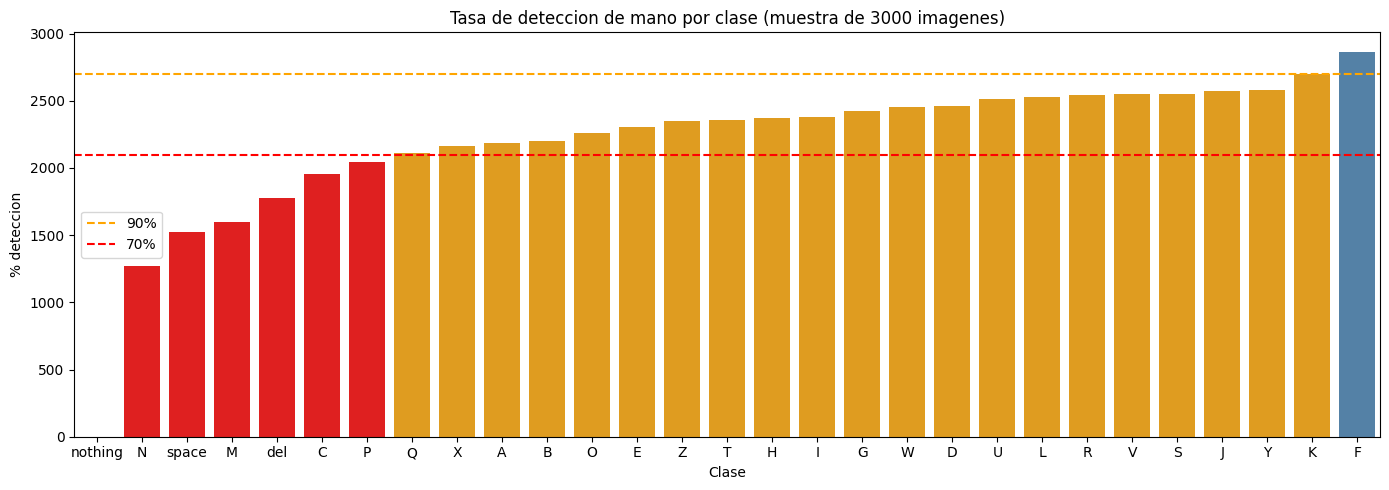

In [21]:
# CELDA 10 - GRAFICO TASA DE DETECCION

df_deteccion = pd.DataFrame(
    list(resultados_deteccion.items()),
    columns=["clase", "tasa_deteccion"]
).sort_values("tasa_deteccion")

plt.figure(figsize=(14, 5))
colores = ["red" if t < 2100 else "orange" if t < 2700 else "steelblue"
           for t in df_deteccion["tasa_deteccion"]]
sns.barplot(data=df_deteccion, x="clase", y="tasa_deteccion", palette=colores)
plt.axhline(y=2700, color="orange", linestyle="--", label="90%")
plt.axhline(y=2100, color="red", linestyle="--", label="70%")
plt.title("Tasa de deteccion de mano por clase (muestra de 3000 imagenes)")
plt.xlabel("Clase")
plt.ylabel("% deteccion")
plt.legend()
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_tasa_deteccion3000.png")
plt.show()

In [23]:
# Probar umbral mas bajo para M y N
base_options_low = python.BaseOptions(model_asset_path=str(model_path))
options_low = vision.HandLandmarkerOptions(
    base_options=base_options_low,
    num_hands=1,
    min_hand_detection_confidence=0.2,
    min_hand_presence_confidence=0.2
)
detector_low = vision.HandLandmarker.create_from_options(options_low)

for clase in ["M", "N", "del"]:
    carpeta = RAW_TRAIN_DIR / clase
    imagenes = list(carpeta.iterdir())[:3000]
    detectadas = 0
    for img_path in imagenes:
        img = mp.Image.create_from_file(str(img_path))
        result = detector_low.detect(img)
        if result.hand_landmarks:
            detectadas += 1
    print(f"{clase}: {detectadas}%")

M: 2158%
N: 1715%
del: 2176%


In [24]:
# Test M y N

for letra, nombre in [("M", "test_M.jpg"), ("N", "test_N.jpg")]:
    img = mp.Image.create_from_file(str(ML_DIR / "data" / nombre))
    result = detector.detect(img)
    if result.hand_landmarks:
        print(f"{letra}: Detectada - {len(result.hand_landmarks[0])} landmarks")
    else:
        print(f"{letra}: No detectada")

M: Detectada - 21 landmarks
N: Detectada - 21 landmarks


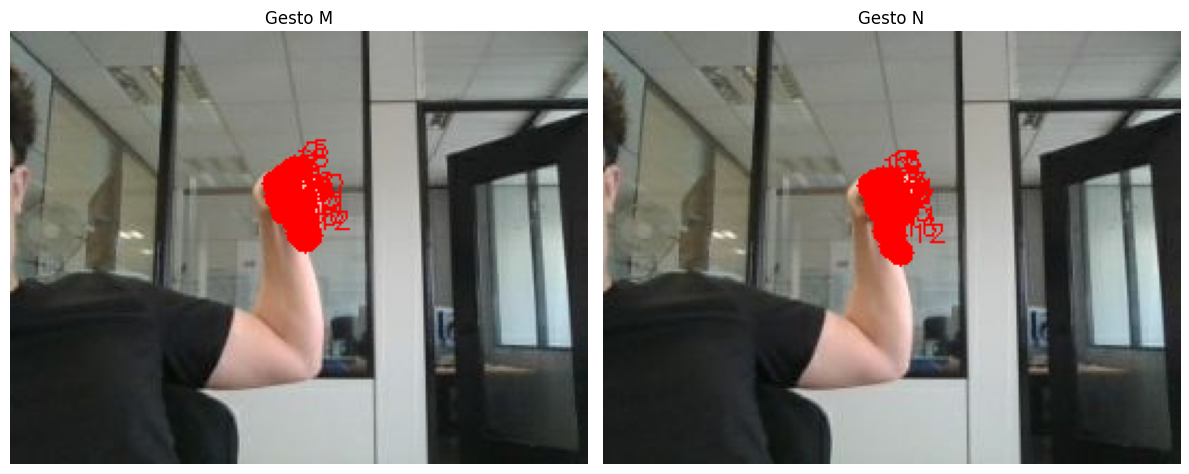

In [25]:
# Test M y N con imagen

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, (letra, nombre) in enumerate([("M", "test_M.jpg"), ("N", "test_N.jpg")]):
    img_cv = cv2.imread(str(ML_DIR / "data" / nombre))
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    result = detector.detect(mp.Image.create_from_file(str(ML_DIR / "data" / nombre)))
    landmarks = result.hand_landmarks[0]
    
    h, w = img_rgb.shape[:2]
    img_landmarks = img_rgb.copy()
    for j, lm in enumerate(landmarks):
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_landmarks, (cx, cy), 6, (255, 0, 0), -1)
        cv2.putText(img_landmarks, str(j), (cx + 5, cy -5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    axes[i].imshow(img_landmarks)
    axes[i].set_title(f"Gesto {letra}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(ML_DIR / "data" / "eda_landmarks_M_N.png")
plt.show()